In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Problem constants
x0 = 0.7
v0 = 1.2
z_min, z_max = 0.0, 20.0
xi_min, xi_max = 0.1, 0.4

In [4]:
class PINN(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=64, num_hidden_layers=4):
        super().__init__()
        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.Tanh())
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z, xi):
        inp = torch.cat([z, xi], dim=1)
        return self.net(inp)

In [5]:
model = PINN().to(device)

In [6]:
def sample_collocation_points(N_f):
    z_f = torch.rand(N_f, 1) * (z_max - z_min) + z_min
    xi_f = torch.rand(N_f, 1) * (xi_max - xi_min) + xi_min
    return z_f.to(device), xi_f.to(device)

def sample_initial_points(N_ic):
    z_ic = torch.zeros(N_ic, 1)
    xi_ic = torch.rand(N_ic, 1) * (xi_max - xi_min) + xi_min
    return z_ic.to(device), xi_ic.to(device)


In [7]:
def derivatives(model, z, xi):
    z.requires_grad_(True)
    xi.requires_grad_(True)

    x = model(z, xi)

    dx_dz = torch.autograd.grad(
        x, z,
        grad_outputs=torch.ones_like(x),
        retain_graph=True,
        create_graph=True
    )[0]

    d2x_dz2 = torch.autograd.grad(
        dx_dz, z,
        grad_outputs=torch.ones_like(dx_dz),
        retain_graph=True,
        create_graph=True
    )[0]

    return x, dx_dz, d2x_dz2

In [8]:
def loss_function(model, N_f=2000, N_ic=200):
    # Collocation points
    z_f, xi_f = sample_collocation_points(N_f)
    x_f, dx_dz_f, d2x_dz2_f = derivatives(model, z_f, xi_f)

    # Physics residual
    residual = d2x_dz2_f + 2.0 * xi_f * dx_dz_f + x_f
    loss_f = torch.mean(residual**2)

    # Initial conditions
    z_ic, xi_ic = sample_initial_points(N_ic)
    x_ic, dx_dz_ic, _ = derivatives(model, z_ic, xi_ic)

    loss_x0 = torch.mean((x_ic - x0)**2)
    loss_v0 = torch.mean((dx_dz_ic - v0)**2)

    loss_ic = loss_x0 + loss_v0
    total_loss = loss_f + loss_ic

    return total_loss, loss_f, loss_ic

In [9]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5000
print_every = 500

for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad()
    loss, loss_f, loss_ic = loss_function(model, N_f=2000, N_ic=200)
    loss.backward()
    optimizer.step()

    if epoch % print_every == 0:
        print(f"Epoch {epoch:5d} | Total: {loss.item():.4e} | "
              f"Physics: {loss_f.item():.4e} | IC: {loss_ic.item():.4e}")


Epoch   500 | Total: 9.4359e-03 | Physics: 9.3785e-03 | IC: 5.7323e-05
Epoch  1000 | Total: 6.3926e-03 | Physics: 6.3132e-03 | IC: 7.9448e-05
Epoch  1500 | Total: 5.8021e-03 | Physics: 5.7770e-03 | IC: 2.5056e-05
Epoch  2000 | Total: 4.4741e-03 | Physics: 4.4204e-03 | IC: 5.3736e-05
Epoch  2500 | Total: 3.8974e-03 | Physics: 3.8713e-03 | IC: 2.6090e-05
Epoch  3000 | Total: 3.9107e-03 | Physics: 3.6384e-03 | IC: 2.7225e-04
Epoch  3500 | Total: 3.0588e-03 | Physics: 3.0087e-03 | IC: 5.0133e-05
Epoch  4000 | Total: 2.9195e-03 | Physics: 2.8869e-03 | IC: 3.2650e-05
Epoch  4500 | Total: 2.6530e-03 | Physics: 2.6255e-03 | IC: 2.7504e-05
Epoch  5000 | Total: 1.9158e-03 | Physics: 1.7314e-03 | IC: 1.8444e-04


In [10]:
import numpy as np

def predict(model, xi_value, num_points=200):
    model.eval()
    with torch.no_grad():
        z = torch.linspace(z_min, z_max, num_points).view(-1, 1).to(device)
        xi = torch.full_like(z, float(xi_value)).to(device)
        x_pred = model(z, xi)
    return z.cpu().numpy().flatten(), x_pred.cpu().numpy().flatten()


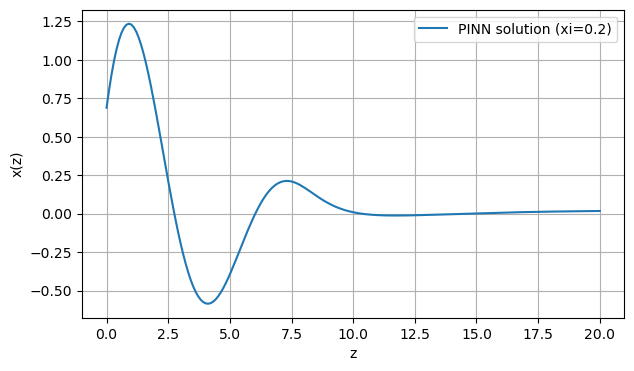

In [11]:
import matplotlib.pyplot as plt

z_grid, x_grid = predict(model, xi_value=0.2)

plt.figure(figsize=(7,4))
plt.plot(z_grid, x_grid, label='PINN solution (xi=0.2)')
plt.xlabel('z')
plt.ylabel('x(z)')
plt.grid(True)
plt.legend()
plt.show()
